# Uncertainty Analysis: Monte Carlo vs Chance-Constrained Optimization

This notebook provides a comprehensive comparison between Monte Carlo and Chance-Constrained (CC) optimization approaches for the ammonia production case study.

## Analysis Components:
1. **CC-Pareto Optimization**: Solving the chance-constrained Pareto problem
2. **Monte Carlo Analysis**: Two uncertainty approaches (custom strategies vs fitted normal)
3. **Comparative Visualization**: Progressive comparison plots
4. **Choice Analysis**: Technology pathway analysis by risk ranges
5. **CC-Pareto Impact Distributions**: Confidence level analysis

All functions are modularized in `a1_uncertainty_mc_utils.py` and `a1_uncertainty_mc_plots.py`.

## Configuration and Setup

In [1]:
# Configuration parameters
FORCE_RECALCULATION = False
N_MC_ITERATIONS = 1500
RANDOM_SEED = 666
SOLVER_NAME = "gurobi"
UNCERTAINTY_CUTOFF = 0.000001
N_TOP_PROCESSES = 19

# File paths
RESULTS_DIR = "data/results"
CC_PARETO_FILE = f"{RESULTS_DIR}/cc_pareto_results.pkl"
MC_STRATEGIES_FILE = f"{RESULTS_DIR}/mc_uncertainty_strategies.pkl"
MC_NORMAL_FILE = f"{RESULTS_DIR}/mc_fitted_normal.pkl"

print("✓ Configuration loaded successfully!")

✓ Configuration loaded successfully!


In [2]:
# Enable automatic reloading of modified modules
%load_ext autoreload
%autoreload 2

# Import required libraries
import os
import numpy as np
import pandas as pd

# Ensure results directory exists
os.makedirs(RESULTS_DIR, exist_ok=True)

# Import our custom modules
import a1_uncertainty_mc_utils as utils
import a1_uncertainty_mc_plots as plots

# PULPO imports
from pulpo import pulpo
from pulpo.utils.uncertainty import processor
import pulpo.utils.uncertainty.monte_carlo as mc

print("✓ All libraries imported successfully!")
print("✓ Autoreload enabled - modules will update automatically when modified!")

✓ All libraries imported successfully!
✓ Autoreload enabled - modules will update automatically when modified!


## 1. PULPO Worker Initialization

Initialize the PULPO worker with the ammonia case study (assuming databases are already installed).

In [3]:
# Project configuration
PROJECT = "ammonia_last"
DATABASE = ["ecoinvent-3.10-cutoff", "ammonia"]
METHOD = "('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')"
DIRECTORY = "develop_tests"

# Initialize PULPO worker
pulpo_worker = pulpo.PulpoOptimizer(PROJECT, DATABASE, METHOD, DIRECTORY)
pulpo_worker.intervention_matrix = "ecoinvent-3.10-biosphere"
pulpo_worker.get_lci_data()

print("\n✓ PULPO worker initialized!")
print(f"  Project: {PROJECT}")
print(f"  Database: {DATABASE}")
print(f"  Method: {METHOD}")


✓ PULPO worker initialized!
  Project: ammonia_last
  Database: ['ecoinvent-3.10-cutoff', 'ammonia']
  Method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')


In [4]:
# Define ammonia problem (choices, demand, upper bounds)
choices, demand = utils.define_ammonia_problem(pulpo_worker)

# Instantiate the problem
pulpo_worker.instantiate(demand=demand, choices=choices)

print("\n✓ Ammonia problem defined and instantiated!")
print(f"  Choices: {len(choices)} technology categories")
print(f"  Demand: {list(demand.values())[0]:.2e} kg/yr ammonia")

Creating Instance
Instance created
Instance created
Creating Instance
Creating Instance
Instance created

✓ Ammonia problem defined and instantiated!
  Choices: 6 technology categories
  Demand: 1.71e+10 kg/yr ammonia
Instance created

✓ Ammonia problem defined and instantiated!
  Choices: 6 technology categories
  Demand: 1.71e+10 kg/yr ammonia


## 2. Chance-Constrained Pareto Optimization

In [5]:
# Run or load CC-Pareto optimization
if utils.check_file_exists(CC_PARETO_FILE, FORCE_RECALCULATION):
    print(f"Loading existing CC-Pareto results from {CC_PARETO_FILE}...")
    cc_pareto_results = utils.load_results(CC_PARETO_FILE)
else:
    print("Running CC-Pareto optimization...")
    
    # Get uncertainty strategies (base iteration)
    unc_strategies = utils.get_uncertainty_strategies(METHOD)
    
    # Import and filter uncertainty data
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF,
        scaling_vector_strategy='constructed_demand',
        plot_results=False,
        plot_n_top_processes=N_TOP_PROCESSES
    )
    
    # Apply base uncertainty strategies
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)
    
    # === SECOND ITERATION: Expert Knowledge Refinement ===
    
    # Get descriptive names of intervention flows for ammonia processes
    If_ammonia_unc = processor.rename_metadata_index(
        pd.DataFrame.from_records(pulpo_worker.uncertainty_data['If']['ammonia']['defined']).T, 
        pulpo_worker.lci_data, 
        'intervention_flow'
    )
    
    # Intervention flows requiring special attention (CO2 from biogas processes)
    If_names = [
        "anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
        "anaerobic digestion of animal manure | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
        "anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')"
    ]
    
    # Extract and refine intervention flow uncertainty
    matched_If_indcs = If_ammonia_unc.loc[If_names, 'index'].values
    matched_If_unc_metadata = {indx: pulpo_worker.uncertainty_data['If']['ammonia']['defined'][indx] for indx in matched_If_indcs}
    processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
    
    # Apply refined bounds for intervention flows
    lower_scaling_factor = .5
    upper_scaling_factor = .1
    for indx, unc_metadata in matched_If_unc_metadata.items():
        matched_If_unc_metadata[indx]['minimum'] = unc_metadata['amount'] - unc_metadata['amount'] * lower_scaling_factor
        matched_If_unc_metadata[indx]['maximum'] = unc_metadata['amount'] + unc_metadata['amount'] * upper_scaling_factor
    processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
    
    # Apply expert knowledge strategy for intervention flows
    epistemic_unc_strategies_iteration_1 = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If',
        uncertain_param_subgroup='ammonia',
        prob_metadata=matched_If_unc_metadata
    )]
    pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_1)
    
    # Get descriptive names of variable bounds for biomass processes
    var_bounds_unc = processor.rename_metadata_index(
        pd.DataFrame.from_records(pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined']).T, 
        pulpo_worker.lci_data, 
        'process'
    )
    
    # Biomass processes requiring special attention (try to match by stripping spaces)
    process_name_patterns = [
        "anaerobic digestion of agricultural residues | biogas | RER",
        "anaerobic digestion of animal manure | biogas | RER",
        "anaerobic digestion of sequential crop | biogas | RER"
    ]
    
    # Find matching process names in the dataframe index
    process_names = []
    for pattern in process_name_patterns:
        matches = [idx for idx in var_bounds_unc.index if pattern in idx]
        if matches:
            process_names.append(matches[0])
        else:
            print(f"Warning: Could not find process matching '{pattern}'")
    
    if not process_names:
        print("ERROR: No matching processes found in var_bounds_unc")
        print(f"Available processes: {list(var_bounds_unc.index)}")
    else:
        # Extract and refine variable bounds uncertainty
        matched_process_indcs = var_bounds_unc.loc[process_names, 'index'].values
        var_bounds_unc_copy = var_bounds_unc.drop(columns=['index'])
        matched_varbound_unc_metadata = {indx: pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined'][indx] for indx in matched_process_indcs}
        
        # Apply refined bounds for variable bounds
        lower_multiplying_factor = .1
        upper_multiplying_factor = 1.1
        for indx, unc_metadata in matched_varbound_unc_metadata.items():
            matched_varbound_unc_metadata[indx]['minimum'] = unc_metadata['amount'] * lower_multiplying_factor
            matched_varbound_unc_metadata[indx]['maximum'] = unc_metadata['amount'] * upper_multiplying_factor
            matched_varbound_unc_metadata[indx]['loc'] = unc_metadata['amount']
            matched_varbound_unc_metadata[indx]['uncertainty_type'] = 5
        processor.fit_normals(matched_varbound_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
        
        # Apply expert knowledge strategy for variable bounds
        epistemic_unc_strategies_iteration_var_bounds = [processor.ExpertKnowledgeStrategy(
            uncertain_param_type='Var_bounds',
            uncertain_param_subgroup='upper_limit',
            prob_metadata=matched_varbound_unc_metadata
        )]
        pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_var_bounds)
        
        # Apply triangular base strategy for variable bounds
        var_bound_strategy = [processor.TriangluarBaseStrategy(
            uncertain_param_type='Var_bounds',
            uncertain_param_subgroup='upper_limit',
            upper_scaling_factor=.001,
            lower_scaling_factor=.001,
            noise_interval={'min': .05, 'max': .05}
        )]
        pulpo_worker.apply_uncertainty_strategies(strategies=var_bound_strategy)
    
    # Create CC formulation
    normal_metadata_env_cost, normal_metadata_var_bounds = pulpo_worker.create_CC_formulation(
        CC_env_cost=True, CC_var_bounds=['upper_limit']
    )
    
    # Solve CC-Pareto problem
    lambda_epsilon_array = np.arange(0.02, 1, 0.02)
    results_CC = pulpo_worker.solve_CC_problem(
        lambda_epsilon_array, normal_metadata_env_cost, normal_metadata_var_bounds, 
        solver_name=SOLVER_NAME
    )
    
    # Package and save results
    cc_pareto_results = {
        'results_CC': results_CC,
        'lambda_epsilon_array': lambda_epsilon_array,
        'normal_metadata_env_cost': normal_metadata_env_cost,
        'normal_metadata_var_bounds': normal_metadata_var_bounds,
        'uncertainty_data': pulpo_worker.uncertainty_data
    }
    utils.save_results(cc_pareto_results, CC_PARETO_FILE)

print(f"\n✓ CC-Pareto optimization completed! Generated {len(cc_pareto_results['results_CC'])} Pareto points")

Loading existing CC-Pareto results from data/results/cc_pareto_results.pkl...
✓ Results loaded from: data/results/cc_pareto_results.pkl

✓ CC-Pareto optimization completed! Generated 49 Pareto points
✓ Results loaded from: data/results/cc_pareto_results.pkl

✓ CC-Pareto optimization completed! Generated 49 Pareto points


## 3. Monte Carlo Analysis (Two Approaches)

Loading existing MC results (strategies) from data/results/mc_uncertainty_strategies.pkl...
✓ Results loaded from: data/results/mc_uncertainty_strategies.pkl

✓ MC analysis with custom strategies completed!
✓ Results loaded from: data/results/mc_uncertainty_strategies.pkl

✓ MC analysis with custom strategies completed!


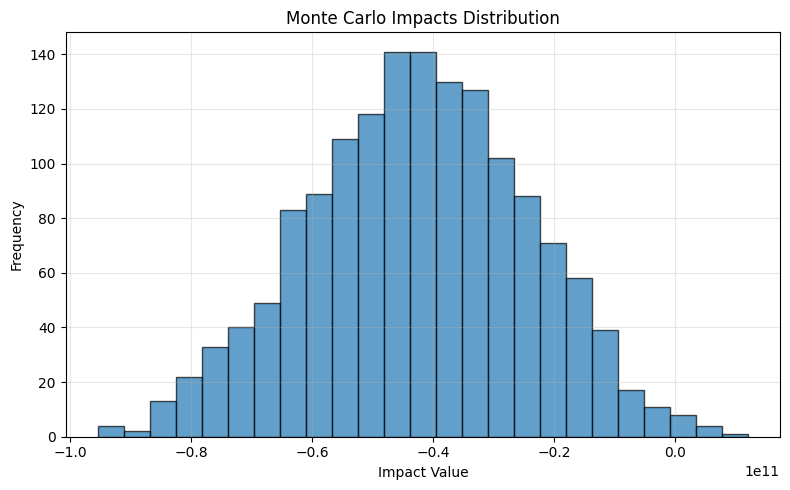


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    1.500000e+03
mean    -4.263342e+10
std      1.818724e+10
min     -9.536799e+10
25%     -5.502391e+10
50%     -4.213914e+10
75%     -2.971980e+10
max      1.195739e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                               times_chosen  \
technology process                                                            
methane    market for biomethane | biomethane, 24 bar | RER            1500   
ammonia    steam reforming, integrated (CCS) | ammonia | RER           1496   
biomethane upgrading chemical scrubbing (CCS) | biomethane...          1474   
biogas     anaerobic digestion of animal manure | biogas |...          1472   
hydrogen   steam methane reforming (CCS) | hydrogen | RER              1471   
heat       heat from hydrogen | hea

In [6]:
# Monte Carlo Analysis 1: Custom Uncertainty Strategies
if utils.check_file_exists(MC_STRATEGIES_FILE, FORCE_RECALCULATION):
    print(f"Loading existing MC results (strategies) from {MC_STRATEGIES_FILE}...")
    mc_strategies_results = utils.load_results(MC_STRATEGIES_FILE)
else:
    print(f"Running Monte Carlo analysis with custom strategies ({N_MC_ITERATIONS} iterations)...")
    
    # Re-define problem for MC analysis
    choices, demand = utils.define_ammonia_problem(pulpo_worker)
    
    # Apply base uncertainty strategies
    unc_strategies = utils.get_uncertainty_strategies(METHOD)
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
        plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
    )
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)
    
    # Apply second iteration expert knowledge refinement (to define all uncertainties)
    If_ammonia_unc = processor.rename_metadata_index(
        pd.DataFrame.from_records(pulpo_worker.uncertainty_data['If']['ammonia']['defined']).T, 
        pulpo_worker.lci_data, 'intervention_flow'
    )
    If_names = [
        "anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
        "anaerobic digestion of animal manure | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
        "anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')"
    ]
    matched_If_indcs = If_ammonia_unc.loc[If_names, 'index'].values
    matched_If_unc_metadata = {indx: pulpo_worker.uncertainty_data['If']['ammonia']['defined'][indx] for indx in matched_If_indcs}
    processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
    
    lower_scaling_factor = .5
    upper_scaling_factor = .1
    for indx, unc_metadata in matched_If_unc_metadata.items():
        matched_If_unc_metadata[indx]['minimum'] = unc_metadata['amount'] - unc_metadata['amount'] * lower_scaling_factor
        matched_If_unc_metadata[indx]['maximum'] = unc_metadata['amount'] + unc_metadata['amount'] * upper_scaling_factor
    processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
    
    epistemic_unc_strategies_iteration_1 = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If', uncertain_param_subgroup='ammonia', prob_metadata=matched_If_unc_metadata
    )]
    pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_1)
    
    var_bounds_unc = processor.rename_metadata_index(
        pd.DataFrame.from_records(pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined']).T, 
        pulpo_worker.lci_data, 'process'
    )
    process_name_patterns = [
        "anaerobic digestion of agricultural residues | biogas | RER",
        "anaerobic digestion of animal manure | biogas | RER",
        "anaerobic digestion of sequential crop | biogas | RER"
    ]
    process_names = [matches[0] for pattern in process_name_patterns 
                     if (matches := [idx for idx in var_bounds_unc.index if pattern in idx])]
    
    if process_names:
        matched_process_indcs = var_bounds_unc.loc[process_names, 'index'].values
        matched_varbound_unc_metadata = {indx: pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined'][indx] 
                                         for indx in matched_process_indcs}
        lower_multiplying_factor, upper_multiplying_factor = .1, 1.1
        for indx, unc_metadata in matched_varbound_unc_metadata.items():
            matched_varbound_unc_metadata[indx].update({
                'minimum': unc_metadata['amount'] * lower_multiplying_factor,
                'maximum': unc_metadata['amount'] * upper_multiplying_factor,
                'loc': unc_metadata['amount'], 'uncertainty_type': 5
            })
        processor.fit_normals(matched_varbound_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
        
        epistemic_unc_strategies_iteration_var_bounds = [processor.ExpertKnowledgeStrategy(
            uncertain_param_type='Var_bounds', uncertain_param_subgroup='upper_limit', 
            prob_metadata=matched_varbound_unc_metadata
        )]
        pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_var_bounds)
        
        var_bound_strategy = [processor.TriangluarBaseStrategy(
            uncertain_param_type='Var_bounds', uncertain_param_subgroup='upper_limit',
            upper_scaling_factor=.001, lower_scaling_factor=.001, noise_interval={'min': .05, 'max': .05}
        )]
        pulpo_worker.apply_uncertainty_strategies(strategies=var_bound_strategy)
    
    mc_strategies_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS, seed=RANDOM_SEED, solver_name=SOLVER_NAME, options=None
    )
    utils.save_results(mc_strategies_results, MC_STRATEGIES_FILE)

print("\n✓ MC analysis with custom strategies completed!")
analysis_strategies = utils.analyze_MC_results(mc_strategies_results, show_plot=True)

Loading existing MC results (normal) from data/results/mc_fitted_normal.pkl...
✓ Results loaded from: data/results/mc_fitted_normal.pkl

✓ MC analysis with normal distributions completed!
✓ Results loaded from: data/results/mc_fitted_normal.pkl

✓ MC analysis with normal distributions completed!


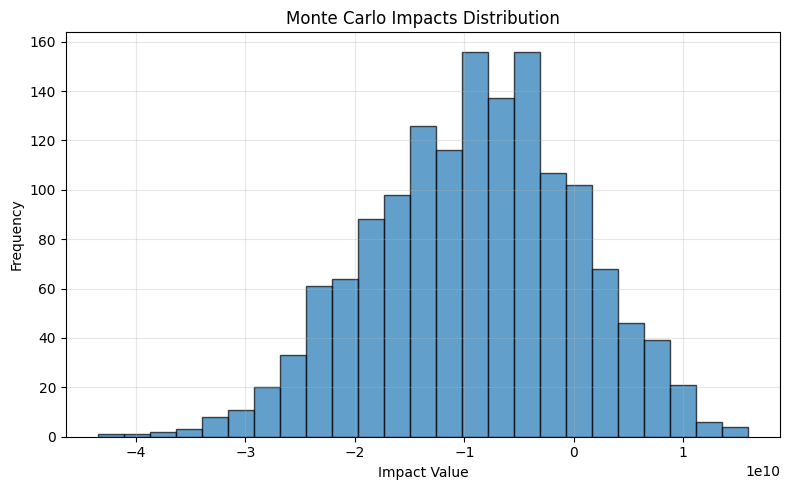


MONTE CARLO ANALYSIS RESULTS

Impact Statistics:
------------------------------------------------------------
count    1.474000e+03
mean    -9.090515e+09
std      9.392292e+09
min     -4.345243e+10
25%     -1.545335e+10
50%     -8.591317e+09
75%     -2.498936e+09
max      1.588016e+10
Name: Impact Value, dtype: float64

Top Choices (by frequency):
------------------------------------------------------------
                                                               times_chosen  \
technology process                                                            
methane    market for biomethane | biomethane, 24 bar | RER            1474   
biogas     anaerobic digestion of animal manure | biogas |...          1449   
biomethane upgrading chemical scrubbing (CCS) | biomethane...          1418   
biogas     anaerobic digestion of agricultural residues | ...          1416   
ammonia    steam reforming, integrated (CCS) | ammonia | RER           1380   
hydrogen   steam methane reforming 

In [7]:
# Monte Carlo Analysis 2: Fitted Normal Distributions
if utils.check_file_exists(MC_NORMAL_FILE, FORCE_RECALCULATION):
    print(f"Loading existing MC results (normal) from {MC_NORMAL_FILE}...")
    mc_normal_results = utils.load_results(MC_NORMAL_FILE)
else:
    print(f"Running Monte Carlo analysis with fitted normal distributions ({N_MC_ITERATIONS} iterations)...")
    
    # Re-define problem for MC analysis
    choices, demand = utils.define_ammonia_problem(pulpo_worker)
    
    # Apply base uncertainty strategies
    unc_strategies = utils.get_uncertainty_strategies(METHOD)
    pulpo_worker.import_and_filter_uncertainty_data(
        cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
        plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
    )
    pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)
    
    # Apply second iteration expert knowledge refinement (to define all uncertainties)
    If_ammonia_unc = processor.rename_metadata_index(
        pd.DataFrame.from_records(pulpo_worker.uncertainty_data['If']['ammonia']['defined']).T, 
        pulpo_worker.lci_data, 'intervention_flow'
    )
    If_names = [
        "anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
        "anaerobic digestion of animal manure | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
        "anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')"
    ]
    matched_If_indcs = If_ammonia_unc.loc[If_names, 'index'].values
    matched_If_unc_metadata = {indx: pulpo_worker.uncertainty_data['If']['ammonia']['defined'][indx] for indx in matched_If_indcs}
    processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
    
    lower_scaling_factor = .5
    upper_scaling_factor = .1
    for indx, unc_metadata in matched_If_unc_metadata.items():
        matched_If_unc_metadata[indx]['minimum'] = unc_metadata['amount'] - unc_metadata['amount'] * lower_scaling_factor
        matched_If_unc_metadata[indx]['maximum'] = unc_metadata['amount'] + unc_metadata['amount'] * upper_scaling_factor
    processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
    
    epistemic_unc_strategies_iteration_1 = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='If', uncertain_param_subgroup='ammonia', prob_metadata=matched_If_unc_metadata
    )]
    pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_1)
    
    var_bounds_unc = processor.rename_metadata_index(
        pd.DataFrame.from_records(pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined']).T, 
        pulpo_worker.lci_data, 'process'
    )
    process_name_patterns = [
        "anaerobic digestion of agricultural residues | biogas | RER",
        "anaerobic digestion of animal manure | biogas | RER",
        "anaerobic digestion of sequential crop | biogas | RER"
    ]
    process_names = [matches[0] for pattern in process_name_patterns 
                     if (matches := [idx for idx in var_bounds_unc.index if pattern in idx])]
    
    if process_names:
        matched_process_indcs = var_bounds_unc.loc[process_names, 'index'].values
        matched_varbound_unc_metadata = {indx: pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined'][indx] 
                                         for indx in matched_process_indcs}
        lower_multiplying_factor, upper_multiplying_factor = .1, 1.1
        for indx, unc_metadata in matched_varbound_unc_metadata.items():
            matched_varbound_unc_metadata[indx].update({
                'minimum': unc_metadata['amount'] * lower_multiplying_factor,
                'maximum': unc_metadata['amount'] * upper_multiplying_factor,
                'loc': unc_metadata['amount'], 'uncertainty_type': 5
            })
        processor.fit_normals(matched_varbound_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)
        
        epistemic_unc_strategies_iteration_var_bounds = [processor.ExpertKnowledgeStrategy(
            uncertain_param_type='Var_bounds', uncertain_param_subgroup='upper_limit', 
            prob_metadata=matched_varbound_unc_metadata
        )]
        pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_var_bounds)
        
        var_bound_strategy = [processor.TriangluarBaseStrategy(
            uncertain_param_type='Var_bounds', uncertain_param_subgroup='upper_limit',
            upper_scaling_factor=.001, lower_scaling_factor=.001, noise_interval={'min': .05, 'max': .05}
        )]
        pulpo_worker.apply_uncertainty_strategies(strategies=var_bound_strategy)
    
    # Transform distributions to normal
    pulpo_worker.uncertainty_data = processor.transform_to_normal(
        pulpo_worker.uncertainty_data, sample_size=100, plot_distribution=False
    )
    
    mc_normal_results = pulpo_worker.run_mc_from_uncertainty(
        n_samples=N_MC_ITERATIONS, seed=RANDOM_SEED, solver_name=SOLVER_NAME, options=None
    )
    utils.save_results(mc_normal_results, MC_NORMAL_FILE)

print("\n✓ MC analysis with normal distributions completed!")
analysis_normal = utils.analyze_MC_results(mc_normal_results, show_plot=True)

## 4. Comparative Analysis and Visualization

In [8]:
# Create comparative summary table
comparison_df = plots.create_summary_table(analysis_strategies, analysis_normal)


COMPARATIVE ANALYSIS - ALL MONTE CARLO APPROACHES

          Approach   Mean Impact      Std Dev    Min Impact   Max Impact      CV (%)
Custom Strategies -4.263342e+10 1.818724e+10 -9.536799e+10 1.195739e+10  -42.659580
    Fitted Normal -9.090515e+09 9.392292e+09 -4.345243e+10 1.588016e+10 -103.319686



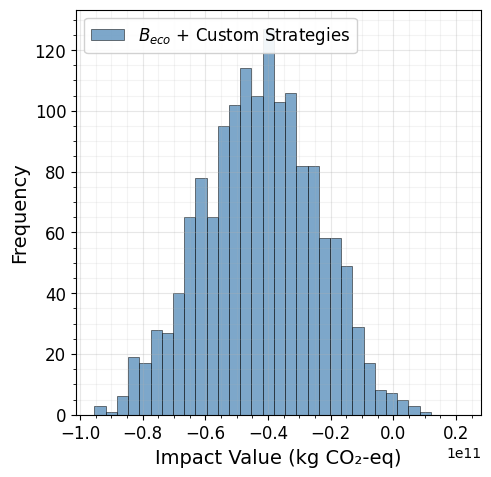

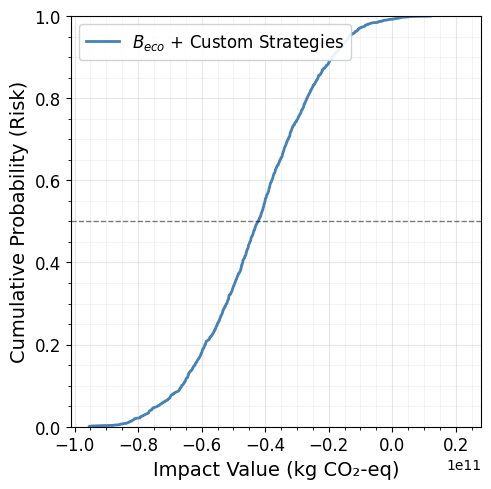

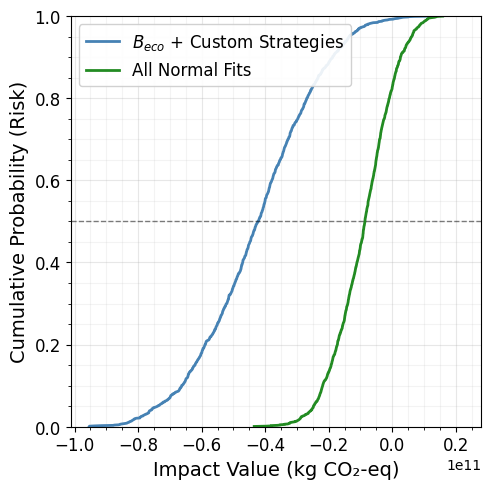

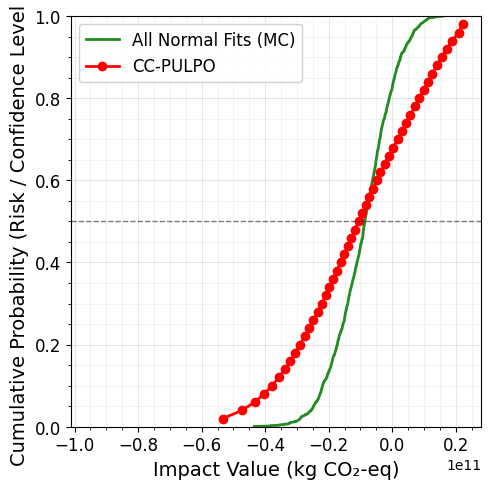


✓ Four progressive comparison plots saved:
  1. data/results/mc_comparison_1_histogram.png - Custom strategies histogram
  2. data/results/mc_comparison_2_cumulative_strategies.png - Custom strategies cumulative risk
  3. data/results/mc_comparison_3_cumulative_all.png - + Normal fits
  4. data/results/mc_comparison_4_cc_vs_mc.png - CC-Pareto vs MC comparison


In [9]:
# Generate progressive comparative plots
plots.plot_comparative_mc_analysis(
    analysis_strategies, analysis_normal, 
    cc_pareto_results, RESULTS_DIR
)

## 5. Choice Analysis within Risk Ranges

In [10]:
# Analyze technology choices across different risk ranges
print("=" * 80)
print("CHOICE ANALYSIS FOR DIFFERENT RISK SCENARIOS")
print("=" * 80)

risk_ranges = [(0.5, 0.6), (0.6, 0.7), (0.7, 0.8), (0.8, 0.9), (0.9, 0.95), (0.95, 1.0)]

risk_analysis_results = {
    f"{int(a*100)}%-{int(b*100)}%": res
    for (a, b) in risk_ranges
    if (res := utils.analyze_choices_in_risk_range(
        mc_normal_results, analysis_normal, a, b, f"{int(a*100)}%-{int(b*100)}%"
    ))
}

print("\n" + "=" * 80)
print("CHOICE ANALYSIS COMPLETE")
print("=" * 80)

CHOICE ANALYSIS FOR DIFFERENT RISK SCENARIOS

50%-60% — Risk 50%–60% | Impact range: [-8.59e+09, -6.19e+09] kg CO₂-eq


KeyError: 'Impacts'

In [ ]:
# Visualize choice analysis
plots.plot_choice_analysis(
    risk_analysis_results, mc_normal_results, 
    f"{RESULTS_DIR}/choice_analysis_by_risk.png"
)

## 6. CC-Pareto Impact Distribution Analysis

In [ ]:
# Generate overlay samples and calculate CC-Pareto impact distributions
N_SAMPLES = 1000
CC_CONFIDENCE_LEVELS = [0.5, 0.74, 0.86, 0.98]

print(f"Generating {N_SAMPLES} overlay samples...")

# Setup uncertainty for overlay sampling (matching CC-Pareto configuration)
unc_strategies = utils.get_uncertainty_strategies(METHOD)
pulpo_worker.import_and_filter_uncertainty_data(
    cutoff=UNCERTAINTY_CUTOFF, scaling_vector_strategy='constructed_demand',
    plot_results=False, plot_n_top_processes=N_TOP_PROCESSES
)
pulpo_worker.apply_uncertainty_strategies(strategies=unc_strategies, plot_results=False)

# === SECOND ITERATION: Expert Knowledge Refinement (matching CC-Pareto setup) ===

# Get descriptive names of intervention flows for ammonia processes
If_ammonia_unc = processor.rename_metadata_index(
    pd.DataFrame.from_records(pulpo_worker.uncertainty_data['If']['ammonia']['defined']).T, 
    pulpo_worker.lci_data, 
    'intervention_flow'
)

If_names = [
    "anaerobic digestion of agricultural residues | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of animal manure | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')",
    "anaerobic digestion of sequential crop | biogas | RER --- Carbon dioxide, in air | ('natural resource', 'in air')"
]

matched_If_indcs = If_ammonia_unc.loc[If_names, 'index'].values
matched_If_unc_metadata = {indx: pulpo_worker.uncertainty_data['If']['ammonia']['defined'][indx] for indx in matched_If_indcs}
processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)

lower_scaling_factor = .5
upper_scaling_factor = .1
for indx, unc_metadata in matched_If_unc_metadata.items():
    matched_If_unc_metadata[indx]['minimum'] = unc_metadata['amount'] - unc_metadata['amount'] * lower_scaling_factor
    matched_If_unc_metadata[indx]['maximum'] = unc_metadata['amount'] + unc_metadata['amount'] * upper_scaling_factor
processor.fit_normals(matched_If_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)

epistemic_unc_strategies_iteration_1 = [processor.ExpertKnowledgeStrategy(
    uncertain_param_type='If',
    uncertain_param_subgroup='ammonia',
    prob_metadata=matched_If_unc_metadata
)]
pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_1)

var_bounds_unc = processor.rename_metadata_index(
    pd.DataFrame.from_records(pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined']).T, 
    pulpo_worker.lci_data, 
    'process'
)

# Biomass processes requiring special attention (try to match by pattern)
process_name_patterns = [
    "anaerobic digestion of agricultural residues | biogas | RER",
    "anaerobic digestion of animal manure | biogas | RER",
    "anaerobic digestion of sequential crop | biogas | RER"
]

# Find matching process names in the dataframe index
process_names = []
for pattern in process_name_patterns:
    matches = [idx for idx in var_bounds_unc.index if pattern in idx]
    if matches:
        process_names.append(matches[0])

if process_names:
    matched_process_indcs = var_bounds_unc.loc[process_names, 'index'].values
    var_bounds_unc_copy = var_bounds_unc.drop(columns=['index'])
    matched_varbound_unc_metadata = {indx: pulpo_worker.uncertainty_data['Var_bounds']['upper_limit']['undefined'][indx] for indx in matched_process_indcs}

    lower_multiplying_factor = .1
    upper_multiplying_factor = 1.1
    for indx, unc_metadata in matched_varbound_unc_metadata.items():
        matched_varbound_unc_metadata[indx]['minimum'] = unc_metadata['amount'] * lower_multiplying_factor
        matched_varbound_unc_metadata[indx]['maximum'] = unc_metadata['amount'] * upper_multiplying_factor
        matched_varbound_unc_metadata[indx]['loc'] = unc_metadata['amount']
        matched_varbound_unc_metadata[indx]['uncertainty_type'] = 5
    processor.fit_normals(matched_varbound_unc_metadata, plot_distributions=False, lci_data=pulpo_worker.lci_data)

    epistemic_unc_strategies_iteration_var_bounds = [processor.ExpertKnowledgeStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        prob_metadata=matched_varbound_unc_metadata
    )]
    pulpo_worker.apply_uncertainty_strategies(strategies=epistemic_unc_strategies_iteration_var_bounds)

    var_bound_strategy = [processor.TriangluarBaseStrategy(
        uncertain_param_type='Var_bounds',
        uncertain_param_subgroup='upper_limit',
        upper_scaling_factor=.001,
        lower_scaling_factor=.001,
        noise_interval={'min': .05, 'max': .05}
    )]
    pulpo_worker.apply_uncertainty_strategies(strategies=var_bound_strategy)

pulpo_worker.create_CC_formulation(CC_env_cost=True, CC_var_bounds=['upper_limit'])

# Generate overlay samples
overlay_samples = mc.pre_sample_from_uncertainty(pulpo_worker, n_samples=N_SAMPLES, seed=RANDOM_SEED)

# Calculate impact distributions for each confidence level
print("\nCalculating impact distributions for CC-Pareto confidence levels:")
impact_distributions = {}

for lambda_val in CC_CONFIDENCE_LEVELS:
    if lambda_val in cc_pareto_results['results_CC']:
        s_vector = cc_pareto_results['results_CC'][lambda_val]['Scaling Vector'].sort_index()
        level_name = f"λ = {lambda_val}"
        impact_distributions[lambda_val] = utils.calculate_impact_distribution(
            overlay_samples, s_vector, level_name
        )
    else:
        print(f"Warning: λ = {lambda_val} not found in CC-Pareto results")

print(f"\n✓ Impact distributions calculated for {len(impact_distributions)} confidence levels")

Generating 1000 overlay samples...
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.475472e+01
Characterized inventory: (2648, 23569) 21677
Filtered characterized inventory: (2648, 23569) 2771
Deviation from LCA score: 0.0008935495831803308
inventory (2648, 23569) filtering resulted in 2771 of 21677 exchanges (99.91% of total impact) and took 0.001 seconds.
CHARACTERIZATION MATRIX (2648,) filtering resulted in 40 of 91 characterization factors
Intervention flows:
In ecoinvent-3.10-cutoff:
chosen environmental impact method: ('IPCC 2013', 'climate change', 'global warming potential (GWP100)', 'uncertain')
The total impact is: 4.475472e+01
Characterized inventory: (2648, 23569) 21677
Filtered characterized inventory: (2648, 23569) 2771
Deviation from LCA score: 0.0008935495831803308
inventory (2648, 23569) filtering resulted in 2771 of 21677 exchanges (99.91% of total impact) and took 0.001 second

Sampling uncertainty draws: 100%|██████████| 1000/1000 [03:00<00:00,  5.54it/s]



Calculating impact distributions for CC-Pareto confidence levels:


ValueError: Different number of diagonals and offsets.

In [ ]:
# Visualize CC-Pareto impact distributions
plots.plot_cc_pareto_distributions(impact_distributions, RESULTS_DIR)

# Create summary statistics table
print("\n" + "="*80)
print("CC-PARETO IMPACT DISTRIBUTION SUMMARY")
print("="*80)

summary_data = []
for lambda_val, impacts in impact_distributions.items():
    summary_data.append({
        'Confidence Level (λ)': lambda_val,
        'Mean Impact': f"{np.mean(impacts):.2e}",
        'Std Dev': f"{np.std(impacts):.2e}",
        'CV (%)': f"{np.std(impacts)/np.mean(impacts)*100:.1f}",
        'Min Impact': f"{np.min(impacts):.2e}",
        'Max Impact': f"{np.max(impacts):.2e}",
        '5th Percentile': f"{np.percentile(impacts, 5):.2e}",
        '95th Percentile': f"{np.percentile(impacts, 95):.2e}"
    })

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print("="*80)

print(f"\n✓ CC-Pareto impact distribution analysis completed!")
print(f"✓ Visualization saved to: {RESULTS_DIR}/cc_pareto_impact_distributions_step*.png")